### Dataset Exploration

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
import os
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

data=[]
labels=[]
classes=43
cur_path=os.getcwd()

#Retrieving the images and their labels
for i in range(classes):
    path=os.path.join(cur_path,'dataset\\Train',str(i))
    images=os.listdir(path)
    
    for a in images:
        try:
            image=Image.open(path+'\\'+a)
            image=image.resize((30,30))
            image=np.array(image)
            data.append(image)
            labels.append(i)
        except Exception as e:
            print('Error loading image: ', e)

data=np.array(data)
labels=np.array(labels)
data.shape, labels.shape

((39209, 30, 30, 3), (39209,))

### Splitting the Dataset

In [7]:
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)
y_train = to_categorical(y_train, classes)
y_test = to_categorical(y_test, classes)
y_train[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 1., 0., 0., 0., 0., 0., 0.])

### Building and Training the CNN Model

In [10]:
model=Sequential()
model.add(Conv2D(filters=32, kernel_size=(5,5), activation='relu', input_shape=X_train.shape[1:]))
model.add(Conv2D(filters=32, kernel_size=(5,5), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(rate=0.25))
model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(rate=0.25))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(rate=0.5))
model.add(Dense(classes, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [11]:
epochs=15
history=model.fit(X_train, y_train, batch_size=64, epochs=epochs, validation_data=(X_test, y_test))

Epoch 1/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.4056 - loss: 2.4685 - val_accuracy: 0.8296 - val_loss: 0.7114
Epoch 2/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - accuracy: 0.7181 - loss: 0.9764 - val_accuracy: 0.9134 - val_loss: 0.3806
Epoch 3/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.7996 - loss: 0.6732 - val_accuracy: 0.9373 - val_loss: 0.2228
Epoch 4/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.8410 - loss: 0.5345 - val_accuracy: 0.9484 - val_loss: 0.1824
Epoch 5/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.8750 - loss: 0.4190 - val_accuracy: 0.9674 - val_loss: 0.1176
Epoch 6/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.9050 - loss: 0.3281 - val_accuracy: 0.9764 - val_loss: 0.0848
Epoch 7/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.9223 - loss: 0.2624 - val_accuracy: 0.9814 - val_loss: 0.0687
Epoch 8/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.9387 - loss: 0.2122 - 

### Plotting Training and Test set Accuracy and Validation

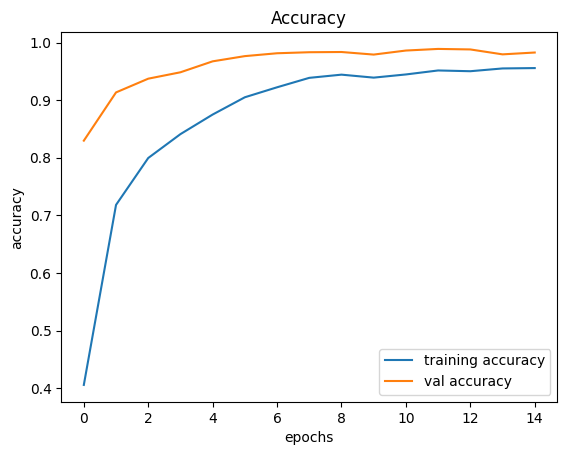

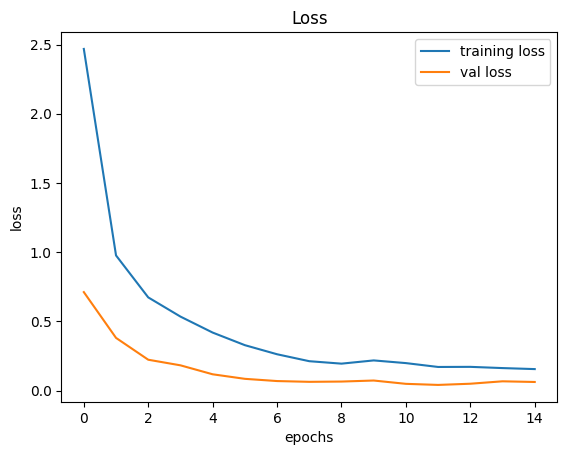

In [12]:
plt.figure(0)
plt.plot(history.history['accuracy'], label='training accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.title('Accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()

plt.figure(1)
plt.plot(history.history['loss'], label='training loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()

### Testing model on Test Data

In [13]:
from sklearn.metrics import accuracy_score
import pandas as pd
y_test_2 = pd.read_csv('dataset/Test.csv')
y_test_2.head()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,53,54,6,5,48,49,16,Test/00000.png
1,42,45,5,5,36,40,1,Test/00001.png
2,48,52,6,6,43,47,38,Test/00002.png
3,27,29,5,5,22,24,33,Test/00003.png
4,60,57,5,5,55,52,11,Test/00004.png


In [19]:
labels=y_test_2['ClassId'].values
images=y_test_2['Path'].values
data=[]
for img in images:
    image=Image.open('dataset\\'+img)
    image=image.resize((30,30))
    data.append(np.array(image))

X_test_2=np.array(data)
# Predictt the first 5 test images
pred=model.predict(X_test_2)
pred=np.argmax(pred, axis=1)

from sklearn.metrics import accuracy_score
accuracy_score(labels, pred)

395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


0.9510688836104513

### Saving the Model

In [20]:
model.save('classifier.keras')